In [1]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
import ast

import _syntax_score_helper_function as ga
import _helper_grammar_functions as jsgo
from _helper_functions import cb
from _helper_functions import dprint


import statsmodels.api as sm
import pandas as pd 
from sklearn.metrics import (confusion_matrix, 
                           accuracy_score)

import scipy.stats as stats


# syntax scores

In [2]:

#  all seqs syntax scored here!!! 09a_PRE_20230926_Predictions-all-lib-seqs__Encoding.ipynb
df=pd.read_pickle(f'F05i-Syntax-Scores/3i-all-seqs.fillNaN.funcAnnotationCol=activity-label.effectSize=odds-ratio.pandas.dataframe.pickle').reset_index(drop=False)

df.head()

,seq,Ma,Ma-sum,Ma-sum-nafill1
0,AAGATAGGCATCTGAAGCTCAAGGAAATTAAATATCTTGCTCACGG...,[1.4241394089768973],1.424139,1.424139
1,AAGATAGGCATCTGAAGCTCAAGGAAATTAAATATCTTGCTCACGG...,[1.4241394089768973],1.424139,1.424139
2,AAGATAGGCATCTGAAGCTCAAGGAAATTAAATATCTTGCTCACTT...,"[1.188727922167361, 2.039352150059302, 2.05631...",7.723005,7.723005
3,AAGATAGGCATCTGAAGCTCAAGGAAATTAAATATCTTGCTCACTT...,[1.188727922167361],1.188728,1.188728
4,AAGATAGGCATCTGAAGCTCAAGGAAATTAAATATCTTGCTCGAGA...,[nan],NaN,1.000000


# enhancer activity

In [3]:
fn='01-Calculate-Enhancer-Activity-Levels/02-generated-tables//endf.rescaledPctl_45_85.wtcollapsed.sumRnaDivSumDna-repSum.pd.df.pickle'
allDF=pd.read_pickle(fn)
allDF.head()

,enhancer-id,enhancer-sites,wt-enhancer-seq,wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,abl-enhancer-seq,abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,act-change-bin,enhancer-dependent-gata-ets
0,Otx-a WT,L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,1.197798,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.848065,"(1, 0)",0
1,ORL351560,L1-G1F-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6,CATCTGAAGCTCGAGATAACTAACGGAAGTTTTCGAAAAGGAAATT...,0.856235,CATCTGAAGCTCGAAATAACTAACGCAAGTTTTCGAAAAGCAAATT...,-1.100699,"(0, -1)",0
2,ORL108031,L1-G1R-L2-E1F-L3-E2F-L4-G2F-L5-G3F-L6,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,0.777169,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.706492,"(0, 0)",0
3,ORL414244,L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3R-L6,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,NaN,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,-1.486866,"(0, -1)",0
4,ORL280162,L1-G1R-L2-E1R-L3-E2F-L4-G2R-L5-G3F-L6,CATCTGAAGCTCGTTATCTCTAACTTCCGTTTTCGAAAAGGAAATT...,0.518839,CATCTGAAGCTCGTTATTTCTAACTTGCGTTTTCGAAAAGCAAATT...,-1.322202,"(0, -1)",0


# combine dataframes

In [4]:
df=df.merge(allDF,left_on='seq',right_on='wt-enhancer-seq')
df.head(1)

,seq,Ma,Ma-sum,Ma-sum-nafill1,enhancer-id,enhancer-sites,wt-enhancer-seq,wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,abl-enhancer-seq,abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,act-change-bin,enhancer-dependent-gata-ets
0,AAGATAGGCATCTGAAGCTCAAGGAAATTAAATATCTTGCTCACGG...,[1.4241394089768973],1.424139,1.424139,ORL437027,L5-G3F-L1-E2F-L2-G2R-L4-E1F-L3-G1F-L6,AAGATAGGCATCTGAAGCTCAAGGAAATTAAATATCTTGCTCACGG...,0.829672,AAAATAGGCATCTGAAGCTCAAGCAAATTAAATATTTTGCTCACGC...,-0.34569,"(0, -1)",0


# FIGURE 2 OLS MASTER TABLE

In [5]:
fn='reference-files/syntax-fam-Bin2Annotation.pydict.pickle'
with open(fn,'rb') as f:
    Bin2Annotation=pickle.load(f)

In [6]:
fn='F03-Syntax-Families/syntax-family-analysis-table-with-permuted-data_numiters=100.pd.df.pickle'
sdf=pd.read_pickle(fn).set_index('syntax-family',drop=False)
sdf.loc[:,'n-func-inert-tuple']=sdf.loc[:,'n-func-inert-tuple'].apply(lambda i: ast.literal_eval(i))
sdf=sdf.loc[:,'n-func-inert-tuple']
sdf.head(1)

syntax-family
L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6    (4, 2)
Name: n-func-inert-tuple, dtype: object

In [7]:
fn='reference-files//OLSName2SyntaxFamily-vary-aff.pydict.pickle'
with open(fn,'rb') as f:
    OLSName2SyntaxFamily=pickle.load(f)
dprint(OLSName2SyntaxFamily)    

L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6 L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6


In [8]:
outdf=df.reset_index(drop=False).loc[:,['seq','enhancer-id','enhancer-sites',
                                       'wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled',
                                       'abl-enhancer-seq','abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled','enhancer-dependent-gata-ets',
                                       'Ma-sum']]

In [9]:
outdf['syntax-fam-bin']=outdf['enhancer-sites'].apply(lambda s: sdf[OLSName2SyntaxFamily[s]])
outdf['syntax-fam-anno']=outdf['syntax-fam-bin'].apply(lambda bi: Bin2Annotation[bi])

In [10]:
outdf=outdf.drop('syntax-fam-bin',axis=1)

In [11]:
old2new={
    'wt-control-name':'Control Name',
    'seq':'Sequence',
    'enhancer-id':'Sequence-id',
    'enhancer-sites':'Site Order',
    'wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled':'WT Activity',
    'abl-enhancer-seq':'ABL Sequence',
    'abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled':'ABL Activity',
    'Ma-sum':'Syntax Score',
    'enhancer-dependent-gata-ets':'Active Dependent on GATA+ETS',
    'syntax-fam-anno':'Syntax Family Label'
}

outdf.columns=[old2new[c] for c in outdf.columns]

In [12]:
outdf['Syntax Score']=outdf['Syntax Score'].fillna(0)
outdf.to_csv('02-Supplemental-Tables/Supplemental-Table-2.tsv',sep='\t',index=None)
outdf.head(1)

,Sequence,Sequence-id,Site Order,WT Activity,ABL Sequence,ABL Activity,Active Dependent on GATA+ETS,Syntax Score,Syntax Family Label
0,AAGATAGGCATCTGAAGCTCAAGGAAATTAAATATCTTGCTCACGG...,ORL437027,L5-G3F-L1-E2F-L2-G2R-L4-E1F-L3-G1F-L6,0.829672,AAAATAGGCATCTGAAGCTCAAGCAAATTAAATATTTTGCTCACGC...,-0.34569,0,1.424139,Moderate


# Fig S15c: Activity of enhancers grouped by syntax score

In [14]:
lowSyntax=5
highSyntax=30
bins=[(0,lowSyntax),(18,22),(highSyntax,max(df['Ma-sum'])+1)]

binstups=pd.IntervalIndex.from_tuples(bins)

data=pd.cut(df['Ma-sum'], binstups).value_counts()

[f'{data[bi]:,}' for bi in binstups]

['202,176', '13,312', '3,602']

In [15]:
df['syntax-bin']=pd.cut(df['Ma-sum-nafill1'], binstups)

/tscc/nfs/home/solvason/miniconda/envs/notebook1/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/tscc/nfs/home/solvason/miniconda/envs/notebook1/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


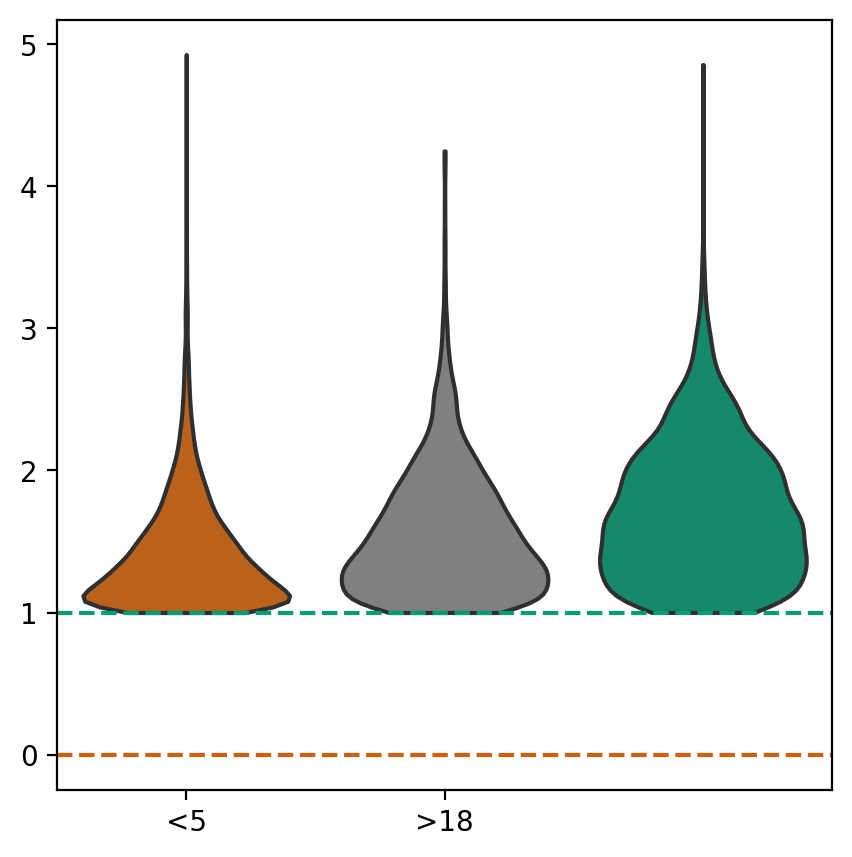

In [16]:

fig,ax=plt.subplots(1,figsize=(5,5),dpi=200)

acol='wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'

inactive   = df['wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled']<1
active     = df['wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled']>=1

depgataets = df['enhancer-dependent-gata-ets']==1

palette=[cb['red'],'grey',cb['green']]
       
sns.violinplot(data=df.loc[ depgataets ,:],x='syntax-bin',y=acol,cut=0,inner=None,palette=palette,scale='width')


ax.set_xlabel('Syntax Score Grouping')
ax.set_xticks([0,1],[f'<{round(bins[0][1])}',f'>{round(bins[1][0])}'])

ax.set_ylabel('')
ax.set_xlabel('')

ax.axhline(0,ls='--',color=cb['red'])
ax.axhline(1,ls='--',color=cb['green'])

plt.show()

ls vs ms
0.0
ls vs hs
0.0


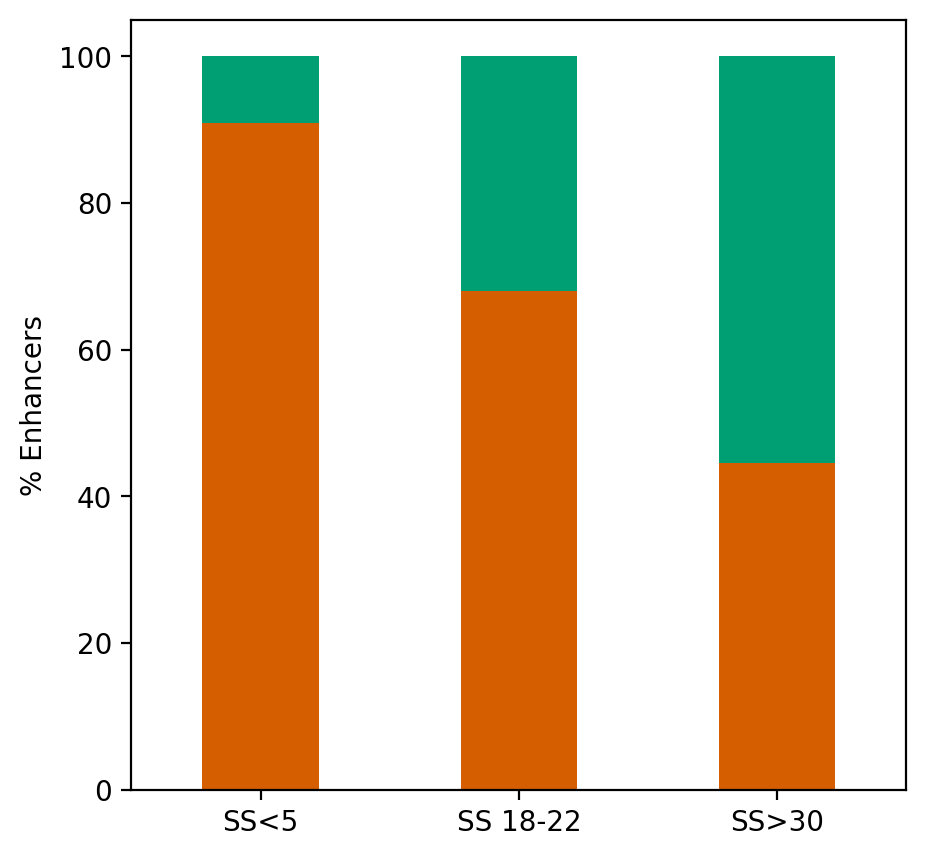

In [17]:
# stacked bar
fig,ax=plt.subplots(1,figsize=(5,5),dpi=200)

acol='wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'

depGataEts=True

# get information about which rows are which 
inactive   = df['wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled']<1
depgataets = df['enhancer-dependent-gata-ets']==1

lowSyntaxRows= df['Ma-sum-nafill1']<lowSyntax
medSyntaxRows= (df['Ma-sum-nafill1']>18) & (df['Ma-sum-nafill1']<22)
highSyntaxRows = df['Ma-sum-nafill1']>highSyntax

# get numbers
il = sum(lowSyntaxRows & inactive)   # inert low syntax
el = sum(lowSyntaxRows & depgataets) # enhancers low syntax
nl = il+el

im = sum(medSyntaxRows & inactive)   # inert low syntax
em = sum(medSyntaxRows & depgataets) # enhancers low syntax
nm = im+em

ih = sum(highSyntaxRows & inactive)   
eh = sum(highSyntaxRows & depgataets) 
nh = ih+eh

# plot
ax.bar(x=0,height=100*il/nl,bottom=0,color=cb['red'],width=.45)
ax.bar(x=0,height=100*el/nl,bottom=100*il/nl,color=cb['green'],width=.45)

ax.bar(x=1,height=100*im/nm,bottom=0,color=cb['red'],width=.45)
ax.bar(x=1,height=100*em/nm,bottom=100*im/nm,color=cb['green'],width=.45)

ax.bar(x=2,height=100*ih/nh,bottom=0,color=cb['red'],width=.45)
ax.bar(x=2,height=100*eh/nh,bottom=100*ih/nh,color=cb['green'],width=.45)

# ax.set_xlabel('Syntax Score Grouping')
ax.set_ylabel('% Enhancers')
ax.set_xticks([0,1],[f'<{round(bins[0][1])}',f'>{round(bins[1][0])}'])

ax.set_xlim(-.5,2.5)

ax.set_xticks([0,1,2],[])

ax.set_xticks([0,1,2],['SS<5','SS 18-22','SS>30'])
# ax.set_yticklabels([])
# ax.set_ylabel('')
ax.set_xlabel('')

# js.clearspines(ax)

print('ls vs ms')
res=stats.fisher_exact([[el, em], [il,im]])
print(res.pvalue)

print('ls vs hs')
res=stats.fisher_exact([[el, eh], [il,ih]])
print(res.pvalue)

# out='000-manuscript-figs/07b_PRE_20230920_Predictions-Using-Grammar__Training__stackedBarSyntaxScore.svg'
# fig.savefig(out,format='svg')